# Telescope vs direct measurement — aug6 side-by-side comparison

Compares the `aug6_telescope_*` scans (camera behind a 2× magnification telescope, y measured
after the f_200mm reference) against the same day's direct `aug6_axicon3_*` scans (y measured
after axicon 3). NO conjugate y mapping is applied — the image↔object offset is not recorded —
so the two datasets sit on their OWN y axes and the comparison is between fit parameters and
profile shapes. The only magnification correction used is the certain transverse one: telescope
k is normalized to ideal k_r3 / M and telescope transverse axes can be divided by M = 2 to give
object-equivalent µm.

Fit machinery is identical to the central-lobe notebooks
(`telescope_central_bessel_lobe_2026_08_06`, `axicon3_central_bessel_lobe_2026_08_05`); the two
datasets share their incremental caches with those notebooks.

| telescope run | placement | anchor (mm) | beam y (cm) | | axicon3 run | placement | anchor (mm) | beam y (cm) |
|---|---|---|---|---|---|---|---|---|
| 18-38-37 | tel_001 | 50 | 5–17 | | 08-38-37 | ax3_007 | 800 | 80–88 |
| 20-57-25 | tel_003 | 250 | 25–37 | | 09-33-56 | ax3_007 | 850 | 85–92 |
| 21-06-22 | tel_005 | 450 | 45–56 | | 09-50-11 | ax3_007 | 900 | 90–102 |
| | | | | | 10-16-44 | ax3_010 | 1000 | 100–112 |
| | | | | | 10-52-08 | ax3_011 | 1100 | 110–122 |
| | | | | | 10-59-06 | ax3_012 | 1300 | 130–142 |
| | | | | | 11-19-48 | ax3_013 | 1300 | 130–142 |
| | | | | | 11-28-06 | ax3_014 | 1400 | 140–152 |
| | | | | | 11-42-44 | ax3_015 | 1500 | 150–162 |
| | | | | | 11-58-30 | ax3_016 | 1600 | 160–172 |
| | | | | | 13-33-08 | ax3_012 | 1200 | 120–132 |

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent

PX_UM = 3.45                       # native camera pixel (µm)
M_TEL = 2.0                        # telescope transverse magnification
ALPHA3_DEG = 0.5

# Per-dataset configuration. Crop/pool per dataset: the telescope core is 2x
# wider on the sensor, so its crop/pool/fit windows are scaled x2 and its
# thumbnails land at 13.8 um/px vs 6.9 um/px direct — the same samples per
# Bessel fringe on both sides.
DS = {
    "telescope": dict(
        prefix="aug6_telescope",
        csv=Path("reductions/telescope_core_frames_2026_08_06.csv"),
        npz=Path("reductions/telescope_core_thumbs_2026_08_06.npz"),
        half_px=288, pool=4, um_per_px=13.8, half_um=993.6, fit_half_um=900.0,
        m=M_TEL, y_label="image-side y after f_200mm (cm)",
        title="2x telescope (image side)"),
    "axicon3": dict(
        prefix="aug6_axicon3",
        csv=Path("reductions/ax3_core_frames_2026_08_06.csv"),
        npz=Path("reductions/ax3_core_thumbs_2026_08_06.npz"),
        half_px=144, pool=2, um_per_px=6.9, half_um=496.8, fit_half_um=450.0,
        m=1.0, y_label="distance after axicon 3 (cm)",
        title="direct (after axicon 3)"),
}

OPTIC_TITLE = ("axicon1,2 alpha = 5.0deg, axicon3 alpha = 0.5deg, "
               "L$_{12}$ separation = 175.0mm, L$_{23}$ separation = 415.0mm")

NOTEBOOK_STEM = "telescope_vs_axicon3_comparison_2026_08_06"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.gcf().savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path}")

In [2]:
# --- core-frame lists, both datasets -----------------------------------------
# Same manifest-only selection as the central-lobe notebooks, per dataset:
#   1. aug6 run dirs with a frames.jsonl, filtered by PlacementID prefix
#      from auto_scan_setup.json; truncated trailing lines skipped w/ warning
#   2. keep ScanKind == "AutoBeamStack", drop '-dark' relabeled proof frames
#   3. per slice, frame rate = Max / Exposure_us; core if rate >= 0.5 x the
#      slice best (bimodal ratio distribution)
#   4. saturated frames KEPT and flagged n_sat_px > 0
#   5. writes each dataset's reductions CSV (shared with its own notebook)
import csv

CORE_RATIO_MIN = 0.5
EXCLUDED = set()          # no junk whole runs identified in either group

core_rows = {}
for ds, d in DS.items():
    rows = []
    scan_dirs = []
    for p in sorted((REPO / "profiler/data").glob("auto_scan-2026-08-06_*")):
        if not (p / "frames.jsonl").exists():
            continue
        try:
            setup = json.loads((p / "auto_scan_setup.json").read_text())
        except (OSError, json.JSONDecodeError) as e:
            print(f"WARNING {p.name}: unreadable auto_scan_setup.json ({e}) — run skipped")
            continue
        if setup.get("PlacementID", "").startswith(d["prefix"]):
            scan_dirs.append(p)
    for run_dir in scan_dirs:
        slices = {}
        for ln, line in enumerate(open(run_dir / "frames.jsonl"), start=1):
            if not line.strip():
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError as e:
                print(f"WARNING {run_dir.name} frames.jsonl:{ln} unparseable "
                      f"({e}) — skipped (run still writing?)")
                continue
            ex = rec.get("Extra", {})
            if ex.get("ScanKind") != "AutoBeamStack":
                continue
            if Path(rec["Path"]).stem.endswith("-dark"):
                continue
            slices.setdefault(ex["Subfolder"], []).append(rec)
        for sub, recs in sorted(slices.items()):
            best = max(r["Max"] / r["Extra"]["Exposure_us"] for r in recs)
            for r in recs:
                rate = r["Max"] / r["Extra"]["Exposure_us"]
                if rate < CORE_RATIO_MIN * best:
                    continue
                rows.append(dict(
                    beam_y_cm=r["Extra"]["BeamY_mm"] / 10.0,
                    run=run_dir.name, slice=sub, frame=Path(r["Path"]).name,
                    gantry_x_mm=r["GantryPosition_mm"]["x_mm"],
                    gantry_z_mm=r["GantryPosition_mm"]["z_mm"],
                    max_counts=r["Max"],
                    exposure_us=round(r["Extra"]["Exposure_us"], 1),
                    rate_c_per_us=round(rate, 4),
                    ratio_to_slice_best=round(rate / best, 3),
                    n_sat_px=r.get("SaturatedPixelCount", 0),
                    excluded_run=run_dir.name in EXCLUDED))
    rows.sort(key=lambda r: (r["beam_y_cm"], r["run"], r["frame"]))
    d["csv"].parent.mkdir(parents=True, exist_ok=True)
    with open(d["csv"], "w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=list(rows[0].keys()))
        w.writeheader(); w.writerows(rows)
    core_rows[ds] = rows
    n_sat = sum(r["n_sat_px"] > 0 for r in rows)
    print(f"{ds}: {len(rows)} core frames from {len(scan_dirs)} runs "
          f"({n_sat} saturated) -> {d['csv']}")

telescope: 92 core frames from 3 runs (3 saturated) -> reductions/telescope_core_frames_2026_08_06.csv
axicon3: 302 core frames from 11 runs (27 saturated) -> reductions/ax3_core_frames_2026_08_06.csv


In [3]:
# --- core-frame thumbnails, both datasets, cached (incremental) --------------
# Same reduction as the central-lobe notebooks, per dataset:
#   1. eligible = analysis rows with n_sat_px == 0
#   2. crop +-half_px native px about the peak pixel (NaN off-sensor),
#      pool x pool mean-pool -> 144x144 thumbnails, raw counts
#   3. INCREMENTAL cache shared with that dataset's own notebook — missing
#      (run, frame) rows are appended; delete an npz to force a full rebuild
import csv

thumbs = {}
for ds, d in DS.items():
    HALF_PX, POOL = d["half_px"], d["pool"]
    rows = [r for r in csv.DictReader(open(d["csv"]))
            if r["excluded_run"] == "False" and int(r["n_sat_px"]) == 0]
    if d["npz"].exists():
        _z = np.load(d["npz"], allow_pickle=True)
        T, Y = _z["thumbs"].astype(np.float32), _z["ys_cm"]
        R, F = _z["runs"], _z["frames"]
        print(f"{ds}: loaded cached thumbnails {T.shape}")
    else:
        T = np.zeros((0, 2 * HALF_PX // POOL, 2 * HALF_PX // POOL), np.float32)
        Y = np.zeros(0); R = F = np.zeros(0, dtype="U8")
    have = set(zip(R.tolist(), F.tolist()))
    todo = [r for r in rows if (r["run"], r["frame"]) not in have]
    if todo:
        new_t, ys_l, runs_l, frames_l = [], [], [], []
        for r in todo:
            p = REPO / "profiler/data" / r["run"] / r["slice"] / r["frame"]
            if not p.exists():
                print(f"MISSING raw frame {p} — left out")
                continue
            a = np.load(p).astype(np.float32)
            iy, ix = np.unravel_index(np.argmax(a), a.shape)
            crop = np.full((2 * HALF_PX, 2 * HALF_PX), np.nan, np.float32)
            y0, y1 = max(iy - HALF_PX, 0), min(iy + HALF_PX, a.shape[0])
            x0, x1 = max(ix - HALF_PX, 0), min(ix + HALF_PX, a.shape[1])
            crop[y0 - (iy - HALF_PX):y0 - (iy - HALF_PX) + (y1 - y0),
                 x0 - (ix - HALF_PX):x0 - (ix - HALF_PX) + (x1 - x0)] = a[y0:y1, x0:x1]
            pl = crop.reshape(HALF_PX * 2 // POOL, POOL, -1, POOL).transpose(0, 2, 1, 3)
            new_t.append(np.nanmean(pl.reshape(pl.shape[0], pl.shape[1], -1), axis=2))
            ys_l.append(float(r["beam_y_cm"])); runs_l.append(r["run"])
            frames_l.append(r["frame"])
        T = np.concatenate([T, np.array(new_t, dtype=np.float32)])
        Y = np.concatenate([Y, np.array(ys_l)])
        R = np.concatenate([R.astype(object), np.array(runs_l, object)])
        F = np.concatenate([F.astype(object), np.array(frames_l, object)])
        np.savez_compressed(d["npz"], thumbs=T.astype(np.float16), ys_cm=Y,
                            runs=R.astype(str), frames=F.astype(str),
                            half_um=d["half_um"], um_per_px=d["um_per_px"])
        print(f"{ds}: reduced and appended {len(new_t)} -> {T.shape[0]} cached")
    thumbs[ds] = dict(t=T, ys=Y, runs=R.astype(str), frames=F.astype(str))
    assert T.shape[0] == len(rows), (
        f"{ds}: cache has {T.shape[0]} thumbs but the list wants {len(rows)} "
        f"— delete {d['npz']} to rebuild")

telescope: loaded cached thumbnails (89, 144, 144)


axicon3: loaded cached thumbnails (275, 144, 144)


In [4]:
# --- 1D J0^2 fits, both datasets ---------------------------------------------
# Identical machinery to the central-lobe notebooks: per fills-the-square
# frame (any NaN in the crop = clipped; per-y backfill keeps the ladder
# complete), X/Z lineouts through the core + azimuthal-mean radial profile
# about the sub-pixel centroid, each fit A*J0^2(k*(u-u0)) + C over
# |u| <= fit_half_um; u0 fixed at 0 for the radial fit. k bounds 0.2-4x the
# dataset's effective ideal (k_r3 for direct, k_r3 / M for the telescope).
import sys
from scipy.optimize import curve_fit
from scipy.special import j0

sys.path.insert(0, str(REPO.parent / "bessel-beam-webapp"))
from simulator.qdht_axicon import axicon_kr

KR_IDEAL = axicon_kr(ALPHA3_DEG)


def j0sq_c(u_um, A, k, u0_um, C):
    return A * j0(k * (u_um - u0_um) * 1e-6) ** 2 + C


FITS = {}
for ds, d in DS.items():
    th = thumbs[ds]
    k_ideal_eff = KR_IDEAL / d["m"]
    fit_half = d["fit_half_um"]
    u0_max = 35.0 * d["m"]

    def fit_profile(u_um, I, free_center=True):
        ok = np.isfinite(I) & (np.abs(u_um) <= fit_half)
        p0 = [np.nanmax(I[ok]), k_ideal_eff, 0.0, 0.0]
        lo = [0, 0.2 * k_ideal_eff, -u0_max, -np.inf]
        hi = [np.inf, 4.0 * k_ideal_eff, u0_max, np.inf]
        if not free_center:
            lo[2], hi[2] = -1e-9, 1e-9
        popt, pcov = curve_fit(j0sq_c, u_um[ok], I[ok], p0=p0, bounds=(lo, hi))
        perr = np.sqrt(np.diag(pcov))
        resid = I[ok] - j0sq_c(u_um[ok], *popt)
        return popt, float(np.sqrt(np.mean(resid ** 2)) / popt[0]), perr

    # fills-the-square + per-y backfill (as in the v2 cells)
    filled = ~np.isnan(th["t"]).any(axis=(1, 2))
    keep = filled.copy()
    frac_on = 1 - np.isnan(th["t"]).mean(axis=(1, 2))
    for y in np.unique(th["ys"]):
        at_y = th["ys"] == y
        if (keep & at_y).any():
            continue
        pick = np.where(at_y)[0][np.argmax(frac_on[at_y])]
        keep[pick] = True
    order = np.lexsort((th["frames"], th["runs"], th["ys"]))
    order = order[keep[order]]

    exp_lookup = {(r["run"], r["frame"]): r["exposure_us"] for r in core_rows[ds]}
    fits = []
    for i in order:
        t = th["t"][i]
        py, px = np.unravel_index(np.nanargmax(t), t.shape)
        x_u = (np.arange(t.shape[1]) - px) * d["um_per_px"]
        z_u = (np.arange(t.shape[0]) - py) * d["um_per_px"]
        w = np.nan_to_num(t[max(py-2, 0):py+3, max(px-2, 0):px+3])
        wy, wx = np.mgrid[max(py-2, 0):py+3, max(px-2, 0):px+3]
        cy, cx = (w*wy).sum()/w.sum(), (w*wx).sum()/w.sum()
        yy, xx = np.mgrid[0:t.shape[0], 0:t.shape[1]]
        r_um = np.hypot(yy - cy, xx - cx) * d["um_per_px"]
        fin = np.isfinite(t)
        b = (r_um[fin] / d["um_per_px"]).astype(int)
        prof = (np.bincount(b, weights=t[fin]) /
                np.maximum(np.bincount(b), 1))
        r_cent = (np.arange(len(prof)) + 0.5) * d["um_per_px"]
        px_fit, rms_x, perr_x = fit_profile(x_u, t[py, :])
        pz_fit, rms_z, perr_z = fit_profile(z_u, t[:, px])
        pr_fit, rms_r, perr_r = fit_profile(r_cent, prof, free_center=False)
        T_exp = exp_lookup[(str(th["runs"][i]), str(th["frames"][i]))]
        fits.append(dict(i=i, y=float(th["ys"][i]), run=str(th["runs"][i]),
                         r=r_cent, Ir=prof, exposure_us=T_exp,
                         px=px_fit, pz=pz_fit, pr=pr_fit,
                         rms=(rms_x, rms_z, rms_r),
                         err=(perr_x, perr_z, perr_r)))
    FITS[ds] = dict(fits=fits, k_ideal_eff=k_ideal_eff)
    kr = np.array([f["pr"][1] for f in fits])
    print(f"{ds}: {len(fits)} frames fit | ideal_eff {k_ideal_eff:.4g} rad/m | "
          f"k_r median {np.median(kr)/k_ideal_eff-1:+.1%} vs ideal_eff, "
          f"IQR {np.percentile(kr,25)/k_ideal_eff-1:+.1%} … "
          f"{np.percentile(kr,75)/k_ideal_eff-1:+.1%}")

telescope: 39 frames fit | ideal_eff 1.934e+04 rad/m | k_r median -10.4% vs ideal_eff, IQR -11.7% … -7.0%


axicon3: 178 frames fit | ideal_eff 3.868e+04 rad/m | k_r median -3.0% vs ideal_eff, IQR -7.6% … +1.5%


saved images/telescope_vs_axicon3_comparison_2026_08_06/cmp_k_vs_y.png


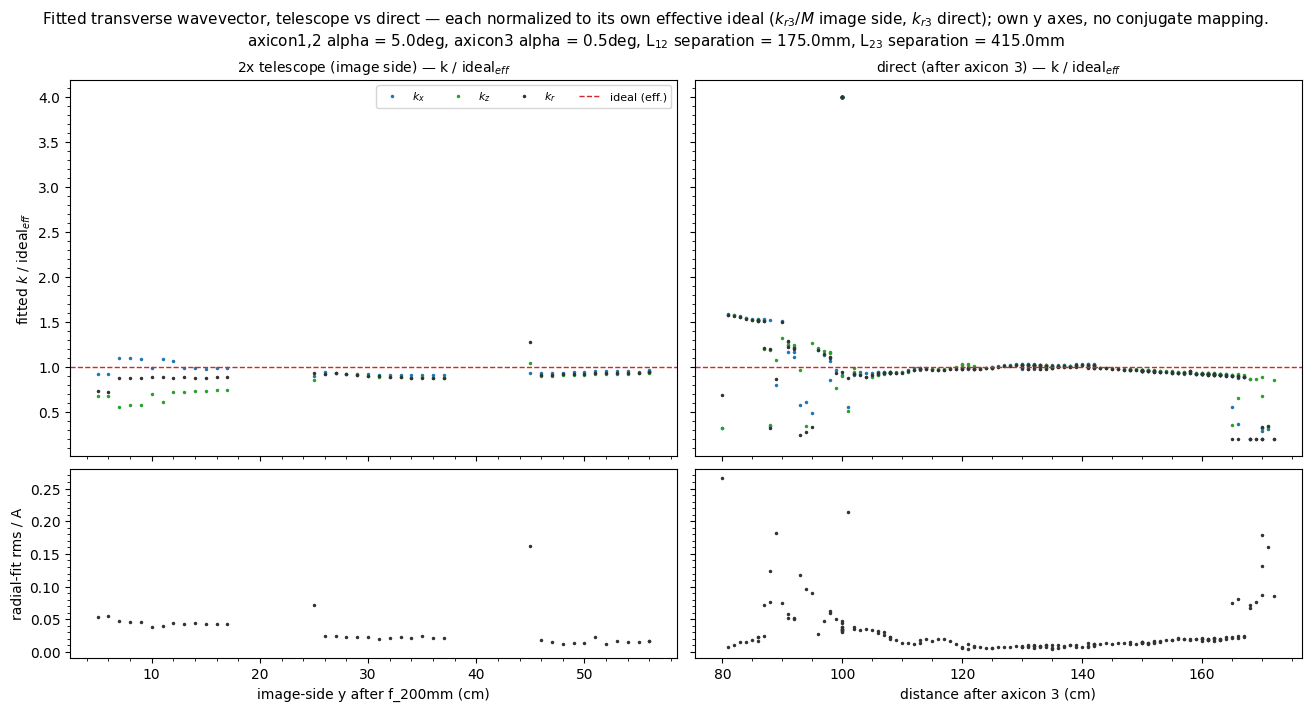

In [5]:
# --- side-by-side: fitted k / effective ideal vs y ---------------------------
# Left: telescope (image-side y, k normalized to k_r3/M). Right: direct
# (y after axicon 3, k normalized to k_r3). Shared normalized ylim so the
# two k ladders can be read against each other without any y mapping.
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharey="row",
                         height_ratios=[2, 1], layout="constrained",
                         sharex="col")
for (ax1, ax2), (ds, d) in zip(axes.T, DS.items()):
    F = FITS[ds]["fits"]; kie = FITS[ds]["k_ideal_eff"]
    ys = np.array([f["y"] for f in F])
    for key, col, lab in (("px", "tab:blue", "$k_x$"),
                          ("pz", "tab:green", "$k_z$"),
                          ("pr", "0.2", "$k_r$")):
        ax1.plot(ys, [f[key][1] / kie for f in F], ".", ms=3, color=col,
                 label=lab)
    ax1.axhline(1.0, color="tab:red", ls="--", lw=1, label="ideal (eff.)")
    ax1.set_title(f"{d['title']} — k / ideal$_{{eff}}$", fontsize=10)
    ax1.minorticks_on()
    ax2.plot(ys, [f["rms"][2] for f in F], ".", ms=3, color="0.2")
    ax2.set_xlabel(d["y_label"])
    ax2.minorticks_on()
axes[0][0].set_ylabel("fitted $k$ / ideal$_{eff}$")
axes[0][0].legend(fontsize=8, ncol=4)
axes[1][0].set_ylabel("radial-fit rms / A")
fig.suptitle("Fitted transverse wavevector, telescope vs direct — each "
             "normalized to its own effective ideal ($k_{r3}/M$ image side, "
             "$k_{r3}$ direct); own y axes, no conjugate mapping.\n"
             + OPTIC_TITLE, fontsize=11)
save_fig("cmp_k_vs_y")
plt.show()

saved images/telescope_vs_axicon3_comparison_2026_08_06/cmp_axial_amplitude.png


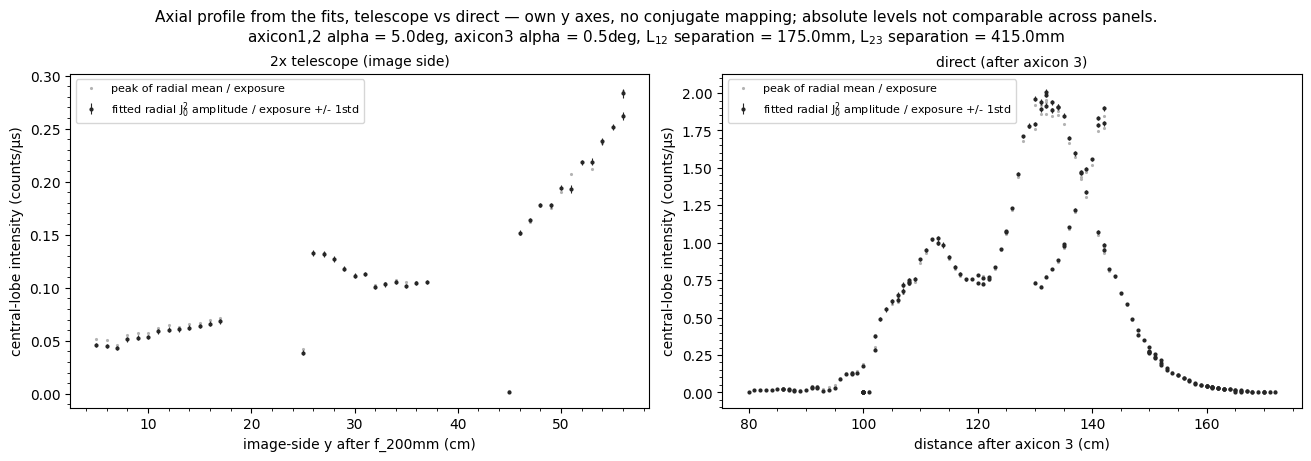

In [6]:
# --- side-by-side: central-lobe amplitude vs y -------------------------------
# Fitted radial J0^2 amplitude / exposure (counts/us) with 1-sigma bars, and
# the same frames' raw peak-pixel rate in gray — per dataset, own axes.
# Absolute levels are NOT comparable across the panels: the telescope spreads
# the core over ~M^2 more sensor area and adds its own transmission.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
for ax, (ds, d) in zip(axes, DS.items()):
    F = FITS[ds]["fits"]
    ys = np.array([f["y"] for f in F])
    A = np.array([f["pr"][0] / f["exposure_us"] for f in F])
    Ae = np.array([f["err"][2][0] / f["exposure_us"] for f in F])
    pk = np.array([f["Ir"].max() / f["exposure_us"] for f in F])
    ax.plot(ys, pk, ".", ms=2.5, color="0.7", label="peak of radial mean / exposure")
    ax.errorbar(ys, A, yerr=Ae, fmt=".", ms=4, color="0.15", elinewidth=0.8,
                label="fitted radial J$_0^2$ amplitude / exposure +/- 1std")
    ax.set_title(d["title"], fontsize=10)
    ax.set_xlabel(d["y_label"])
    ax.set_ylabel("central-lobe intensity (counts/µs)")
    ax.minorticks_on()
    ax.legend(fontsize=8)
fig.suptitle("Axial profile from the fits, telescope vs direct — own y axes, "
             "no conjugate mapping; absolute levels not comparable across "
             "panels.\n" + OPTIC_TITLE, fontsize=11)
save_fig("cmp_axial_amplitude")
plt.show()

telescope: 2/38 y values have no clean fit (rms/A > 0.06) — left out of the family
axicon3: 14/93 y values have no clean fit (rms/A > 0.06) — left out of the family


saved images/telescope_vs_axicon3_comparison_2026_08_06/cmp_radial_profiles.png


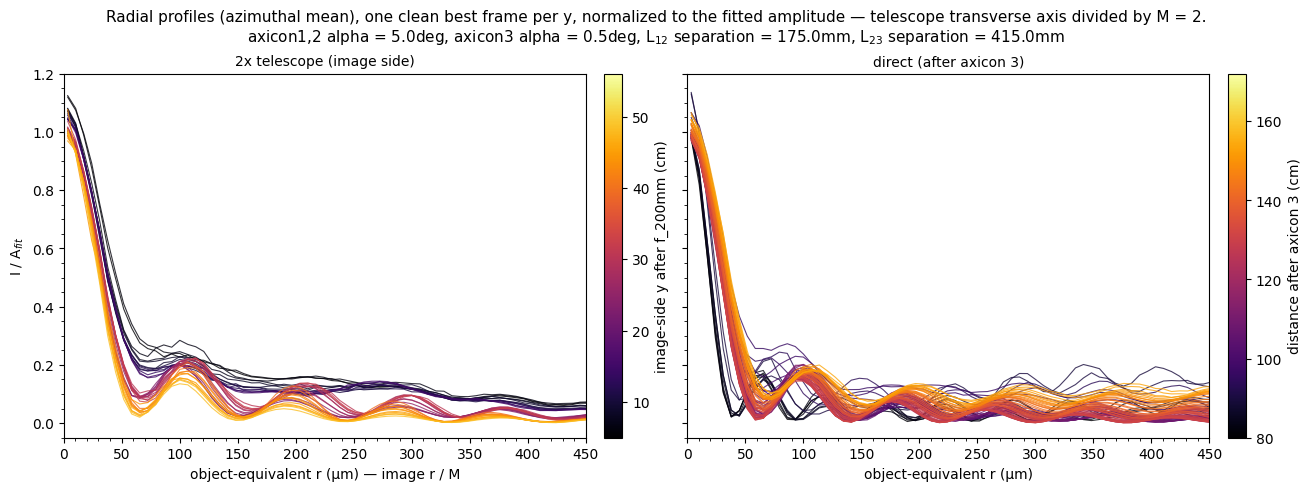

In [7]:
# --- radial profile families in object-equivalent µm -------------------------
# One best frame per y (largest fitted A among clean fits, rms_r <= 0.06 —
# the fit_ok cut; fall back to all candidates if a y has none), radial
# profiles normalized to their fitted amplitude. The telescope's transverse
# axis is divided by M = 2 (object-equivalent µm) — the one magnification-
# only correction that needs no conjugate mapping — so identical beams give
# identical curves here. Color = y along each dataset's own ladder.
from matplotlib import colormaps
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

RMS_OK = 0.06
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True,
                         layout="constrained")
cmap_l = colormaps["inferno"]
for ax, (ds, d) in zip(axes, DS.items()):
    F = FITS[ds]["fits"]
    best = {}
    for f in F:
        cur = best.get(f["y"])
        f_ok = f["rms"][2] <= RMS_OK
        if cur is None:
            best[f["y"]] = f
            continue
        cur_ok = cur["rms"][2] <= RMS_OK
        if (f_ok, f["pr"][0]) > (cur_ok, cur["pr"][0]):
            best[f["y"]] = f
    ys_all = sorted(best)
    norm = Normalize(min(ys_all), max(ys_all))
    n_dirty = 0
    for y in ys_all:
        f = best[y]
        if f["rms"][2] > RMS_OK:
            n_dirty += 1
            continue
        ax.plot(f["r"] / d["m"], f["Ir"] / f["pr"][0], "-", lw=0.8,
                alpha=0.8, color=cmap_l(0.85 * norm(f["y"])))
    if n_dirty:
        print(f"{ds}: {n_dirty}/{len(ys_all)} y values have no clean fit "
              f"(rms/A > {RMS_OK}) — left out of the family")
    ax.set_xlim(0, 450)
    ax.set_ylim(-0.05, 1.2)
    ax.set_xlabel("object-equivalent r (µm)"
                  + (" — image r / M" if d["m"] != 1 else ""))
    ax.set_title(d["title"], fontsize=10)
    ax.minorticks_on()
    fig.colorbar(ScalarMappable(norm=norm, cmap=cmap_l), ax=ax, pad=0.01,
                 label=d["y_label"])
axes[0].set_ylabel("I / A$_{fit}$")
fig.suptitle("Radial profiles (azimuthal mean), one clean best frame per y, "
             "normalized to the fitted amplitude — telescope transverse axis "
             "divided by M = 2.\n" + OPTIC_TITLE, fontsize=11)
save_fig("cmp_radial_profiles")
plt.show()